In [ ]:
!pip install torch numpy matplotlib

In [ ]:

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


max Doppler shift: 17.8816


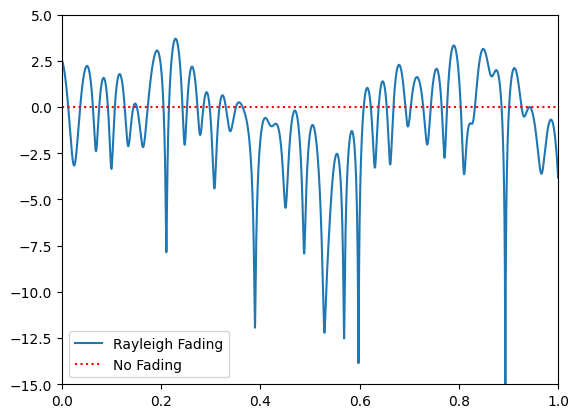

In [ ]:

def generate_rayleigh_data(N=10000):
    v_mph = 60 # velocity of either TX or RX, in miles per hour
    center_freq = 200e6 # RF carrier frequency in Hz
    Fs = 1e5 # sample rate of simulation

    v = v_mph * 0.44704 # convert to m/s
    fd = v*center_freq/3e8 # max Doppler shift
    print("max Doppler shift:", fd)
    t = np.arange(0, 1, 1/Fs) # time vector. (start, stop, step)
    x = np.zeros(len(t))
    y = np.zeros(len(t))
    for i in range(N):
        alpha = (np.random.rand() - 0.5) * 2 * np.pi
        phi = (np.random.rand() - 0.5) * 2 * np.pi
        x = x + np.random.randn() * np.cos(2 * np.pi * fd * t * np.cos(alpha) + phi)
        y = y + np.random.randn() * np.sin(2 * np.pi * fd * t * np.cos(alpha) + phi)

    # z is the complex coefficient representing channel, you can think of this as a phase shift and magnitude scale
    z = (1/np.sqrt(N)) * (x + 1j*y) # this is what you would actually use when simulating the channel
    z_mag = np.abs(z) # take magnitude for the sake of plotting
    z_mag_dB = 10*np.log10(z_mag) # convert to dB

    # Plot fading over time
    plt.plot(t, z_mag_dB)
    plt.plot([0, 1], [0, 0], ':r') # 0 dB
    plt.legend(['Rayleigh Fading', 'No Fading'])
    plt.axis([0, 1, -15, 5])
    plt.show()
    return z_mag_dB

data = generate_rayleigh_data()

In [ ]:
print(data[:10])
print(type(data))

[2.51866945 2.51787686 2.51708224 2.51628558 2.51548689 2.51468616
 2.5138834  2.5130786  2.51227177 2.51146291]
<class 'numpy.ndarray'>


In [ ]:

def create_dataset(data, seq_len=10, pred_step=1):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_step):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len+pred_step-1])
    return np.array(X), np.array(y)

def prepare_data(seq_len=10, pred_step=1):
    X, y = create_dataset(data, seq_len, pred_step)

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = prepare_data()

In [ ]:
class RNNModel(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(1, hidden_size, batch_first=True, dropout=0.2)
        self.Norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size,64),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.Norm(out)
        return self.fc(out).squeeze()


class LSTMModel(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True, dropout=0.2)
        self.Norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.Norm(out)
        return self.fc(out).squeeze()


class GRUModel(nn.Module):
    def __init__(self, hidden_size, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, num_layers=num_layers, batch_first=True)
        self.Norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.Norm(out)
        return self.fc(out).squeeze()

In [ ]:
def train_model(model, X_train, y_train, X_test=None, y_test=None, epochs=50):
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()
        optimizer.zero_grad()

        output = model(X_train)
        print(output)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if X_test is not None:
            model.eval()
            with torch.no_grad():
                val_output = model(X_test)
                val_loss = criterion(val_output, y_test).item()
                val_losses.append(val_loss)


        if (epoch + 1) % 25 == 0:
            if X_test is not None:
                print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss:.6f}")
            else:
                print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.6f}")

    return model, train_losses, val_losses

In [ ]:
def evaluate(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        pred = model(X_test)
        mse = nn.MSELoss()(pred, y_test).item()
    return mse, pred.cpu().numpy()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:641: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__(mode, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)



Training RNN...
tensor([ 0.2981, -0.0993,  0.2159,  ...,  0.3023,  0.0324,  0.0802],
       grad_fn=<SqueezeBackward0>)
tensor([0.1963, 0.3681, 0.0612,  ..., 0.2835, 0.2264, 0.1394],
       grad_fn=<SqueezeBackward0>)

Training LSTM...
tensor([-0.4595, -0.5893, -0.4201,  ..., -0.3309, -0.3889, -0.3579],
       grad_fn=<SqueezeBackward0>)
tensor([-0.5057, -0.5052, -0.4980,  ..., -0.4196, -0.5820, -0.5110],
       grad_fn=<SqueezeBackward0>)

Training Deep GRU...
tensor([ 0.0015, -0.1111, -0.2159,  ..., -0.1489, -0.1076, -0.0052],
       grad_fn=<SqueezeBackward0>)
tensor([ 0.0144, -0.2572, -0.2236,  ..., -0.2197, -0.1383, -0.0489],
       grad_fn=<SqueezeBackward0>)

MSE Results: {'RNN': 8.78464412689209, 'LSTM': 10.265317916870117, 'Deep GRU': 9.390259742736816}


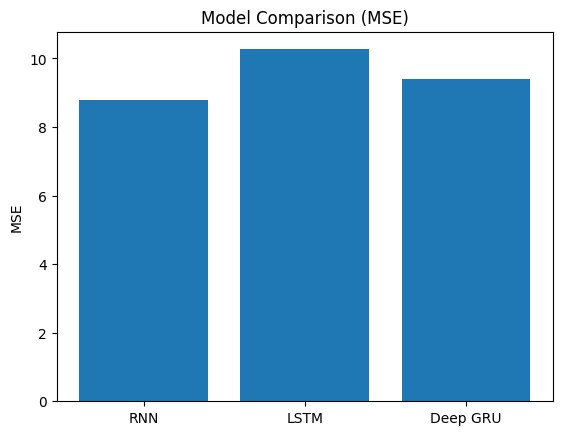

In [ ]:
models = {
    "RNN": RNNModel(30),
    "LSTM": LSTMModel(30),
    # "GRU": GRUModel(30),
    "Deep GRU": GRUModel(30, num_layers=2)
}

results = {}
loss_history = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    trained_model, train_loss, val_loss = train_model(
        model, X_train, y_train, X_test, y_test, epochs=2
    )

    mse, pred = evaluate(trained_model, X_test, y_test)

    results[name] = mse
    loss_history[name] = (train_loss, val_loss)

print("\nMSE Results:", results)


plt.bar(results.keys(), results.values())
plt.title("Model Comparison (MSE)")
plt.ylabel("MSE")
plt.show()

Epoch 25/50 | Train Loss: 5.321968
Epoch 50/50 | Train Loss: 3.265408
Epoch 25/50 | Train Loss: 4.585114
Epoch 50/50 | Train Loss: 3.164272
Epoch 25/50 | Train Loss: 5.263745
Epoch 50/50 | Train Loss: 3.591213
Epoch 25/50 | Train Loss: 3.993268
Epoch 50/50 | Train Loss: 2.168161
Epoch 25/50 | Train Loss: 3.193118
Epoch 50/50 | Train Loss: 1.884577
Epoch 25/50 | Train Loss: 3.448089
Epoch 50/50 | Train Loss: 1.944371
Epoch 25/50 | Train Loss: 2.014141
Epoch 50/50 | Train Loss: 1.276434
Epoch 25/50 | Train Loss: 3.062422
Epoch 50/50 | Train Loss: 1.646424
Epoch 25/50 | Train Loss: 3.823711
Epoch 50/50 | Train Loss: 2.042390
Epoch 25/50 | Train Loss: 1.859731
Epoch 50/50 | Train Loss: 1.126807
Epoch 25/50 | Train Loss: 1.894728
Epoch 50/50 | Train Loss: 1.155732
Epoch 25/50 | Train Loss: 2.231953
Epoch 50/50 | Train Loss: 1.381122
Epoch 25/50 | Train Loss: 1.608059
Epoch 50/50 | Train Loss: 0.895778
Epoch 25/50 | Train Loss: 1.670778
Epoch 50/50 | Train Loss: 0.984537
Epoch 25/50 | Train 

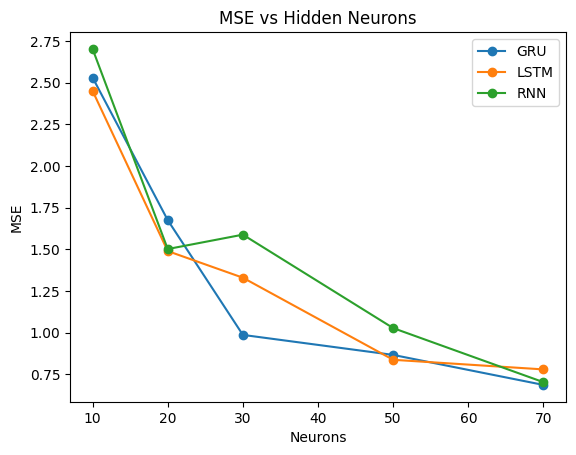

In [ ]:

neurons = [10,20, 30, 50, 70]
mse_gru = []
mse_lstm = []
mse_rnn = []

for n in neurons:
    model_GRU = GRUModel(n,2)
    model_LSTM = LSTMModel(n)
    model_RNN = RNNModel(n)
    trained_gru,_,_ = train_model(model_GRU, X_train, y_train)
    mse_val1, _ = evaluate(trained_gru, X_test, y_test)
    mse_gru.append(mse_val1)
    trained_lstm,_,_ = train_model(model_LSTM, X_train, y_train)
    mse_val2, _ = evaluate(trained_lstm, X_test, y_test)
    mse_lstm.append(mse_val2)
    trained_rnn,_,_ = train_model(model_RNN, X_train, y_train)
    mse_val3, _ = evaluate(trained_rnn, X_test, y_test)
    mse_rnn.append(mse_val3)

plt.plot(neurons, mse_gru, marker='o')
plt.plot(neurons, mse_lstm, marker='o')
plt.plot(neurons, mse_rnn, marker='o')
plt.title("MSE vs Hidden Neurons")
plt.xlabel("Neurons")
plt.ylabel("MSE")
plt.legend(["GRU", "LSTM", "RNN"])
plt.show()

Epoch 10/50 | Train Loss: 6.904716
Epoch 20/50 | Train Loss: 5.320725
Epoch 30/50 | Train Loss: 4.477424
Epoch 40/50 | Train Loss: 3.963263
Epoch 50/50 | Train Loss: 3.504211
Epoch 10/50 | Train Loss: 7.869396
Epoch 20/50 | Train Loss: 6.128681
Epoch 30/50 | Train Loss: 4.962063
Epoch 40/50 | Train Loss: 4.211922
Epoch 50/50 | Train Loss: 3.707950
Epoch 10/50 | Train Loss: 9.285810
Epoch 20/50 | Train Loss: 6.711180
Epoch 30/50 | Train Loss: 5.062239
Epoch 40/50 | Train Loss: 4.103331
Epoch 50/50 | Train Loss: 3.510103
Epoch 10/50 | Train Loss: 9.182909
Epoch 20/50 | Train Loss: 6.995255
Epoch 30/50 | Train Loss: 5.460562
Epoch 40/50 | Train Loss: 4.410819
Epoch 50/50 | Train Loss: 3.820821
Epoch 10/50 | Train Loss: 9.020230
Epoch 20/50 | Train Loss: 7.018974
Epoch 30/50 | Train Loss: 5.589387
Epoch 40/50 | Train Loss: 4.643453
Epoch 50/50 | Train Loss: 4.047483
Epoch 10/50 | Train Loss: 8.285728
Epoch 20/50 | Train Loss: 6.453897
Epoch 30/50 | Train Loss: 5.098962
Epoch 40/50 | Train 

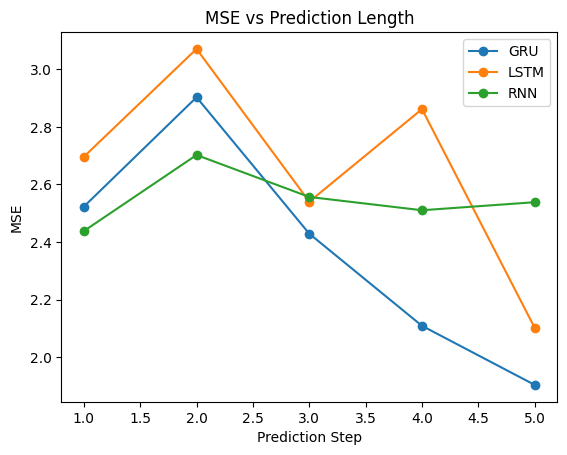

In [ ]:

steps = [1, 2, 3, 4, 5]
mse_steps_gru = []
mse_steps_lstm = []
mse_steps_rnn = []

for step in steps:
    X_train, y_train, X_test, y_test = prepare_data(pred_step=step)
    model_GRU = GRUModel(30,2)
    model_LSTM = LSTMModel(30)
    model_RNN = RNNModel(30)
    trained_gru,_,_ = train_model(model_GRU, X_train, y_train)
    mse_val1, _ = evaluate(trained_gru, X_test, y_test)
    mse_steps_gru.append(mse_val1)
    trained_lstm,_,_ = train_model(model_LSTM, X_train, y_train)
    mse_val2, _ = evaluate(trained_lstm, X_test, y_test)
    mse_steps_lstm.append(mse_val2)
    trained_rnn,_,_ = train_model(model_RNN, X_train, y_train)
    mse_val3, _ = evaluate(trained_rnn, X_test, y_test)
    mse_steps_rnn.append(mse_val3)


plt.plot(steps, mse_steps_gru, marker='o')
plt.plot(steps, mse_steps_lstm, marker='o')
plt.plot(steps, mse_steps_rnn, marker='o')
plt.title("MSE vs Prediction Length")
plt.xlabel("Prediction Step")
plt.ylabel("MSE")
plt.legend(["GRU", "LSTM", "RNN"])
plt.show()

Epoch 25/50 | Train Loss: 4.297164
Epoch 50/50 | Train Loss: 3.514452
Epoch 25/50 | Train Loss: 5.523820
Epoch 50/50 | Train Loss: 4.157906
Epoch 25/50 | Train Loss: 5.237417
Epoch 50/50 | Train Loss: 4.308934
Epoch 25/50 | Train Loss: 3.547902
Epoch 50/50 | Train Loss: 2.359709
Epoch 25/50 | Train Loss: 3.617547
Epoch 50/50 | Train Loss: 2.545349
Epoch 25/50 | Train Loss: 3.297387
Epoch 50/50 | Train Loss: 2.531538
Epoch 25/50 | Train Loss: 2.715700
Epoch 50/50 | Train Loss: 1.560231
Epoch 25/50 | Train Loss: 2.899680
Epoch 50/50 | Train Loss: 1.779991
Epoch 25/50 | Train Loss: 2.940141
Epoch 50/50 | Train Loss: 1.793389
Epoch 25/50 | Train Loss: 2.388122
Epoch 50/50 | Train Loss: 1.488389
Epoch 25/50 | Train Loss: 3.014075
Epoch 50/50 | Train Loss: 1.803963
Epoch 25/50 | Train Loss: 2.653368
Epoch 50/50 | Train Loss: 1.700109


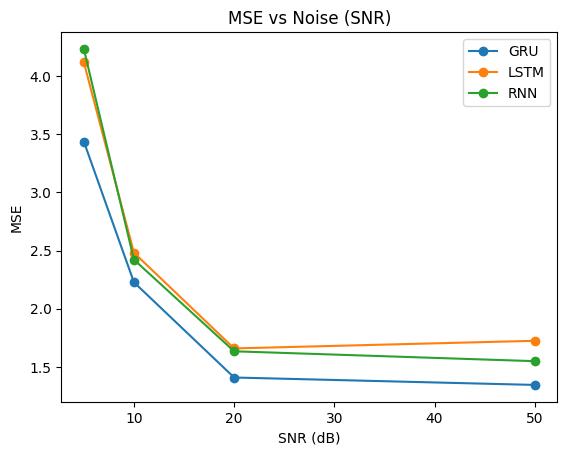

In [ ]:

def add_noise(data, snr_db):
    signal_power = np.mean(data**2)
    snr = 10**(snr_db / 10)
    noise_power = signal_power / snr
    noise = np.sqrt(noise_power) * np.random.randn(len(data))
    return data + noise

snrs = [5, 10, 20, 50]
mse_noise_gru = []
mse_noise_lstm = []
mse_noise_rnn = []

for snr in snrs:
    noisy_data = add_noise(data, snr)
    X, y = create_dataset(noisy_data)

    split = int(0.75 * len(X))
    X_train = torch.tensor(X[:split], dtype=torch.float32).unsqueeze(-1).to(device)
    y_train = torch.tensor(y[:split], dtype=torch.float32).to(device)
    X_test = torch.tensor(X[split:], dtype=torch.float32).unsqueeze(-1).to(device)
    y_test = torch.tensor(y[split:], dtype=torch.float32).to(device)

    model_GRU = GRUModel(30,2)
    model_LSTM = LSTMModel(30)
    model_RNN = RNNModel(30)
    trained_gru,_,_ = train_model(model_GRU, X_train, y_train)
    mse_val1, _ = evaluate(trained_gru, X_test, y_test)
    mse_noise_gru.append(mse_val1)
    trained_lstm,_,_ = train_model(model_LSTM, X_train, y_train)
    mse_val2, _ = evaluate(trained_lstm, X_test, y_test)
    mse_noise_lstm.append(mse_val2)
    trained_rnn,_,_ = train_model(model_RNN, X_train, y_train)
    mse_val3, _ = evaluate(trained_rnn, X_test, y_test)
    mse_noise_rnn.append(mse_val3)

plt.plot(snrs, mse_noise_gru, marker='o')
plt.plot(snrs, mse_noise_lstm, marker='o')
plt.plot(snrs, mse_noise_rnn, marker='o')
plt.title("MSE vs Noise (SNR)")
plt.xlabel("SNR (dB)")
plt.ylabel("MSE")
plt.legend(["GRU", "LSTM", "RNN"])
plt.show()

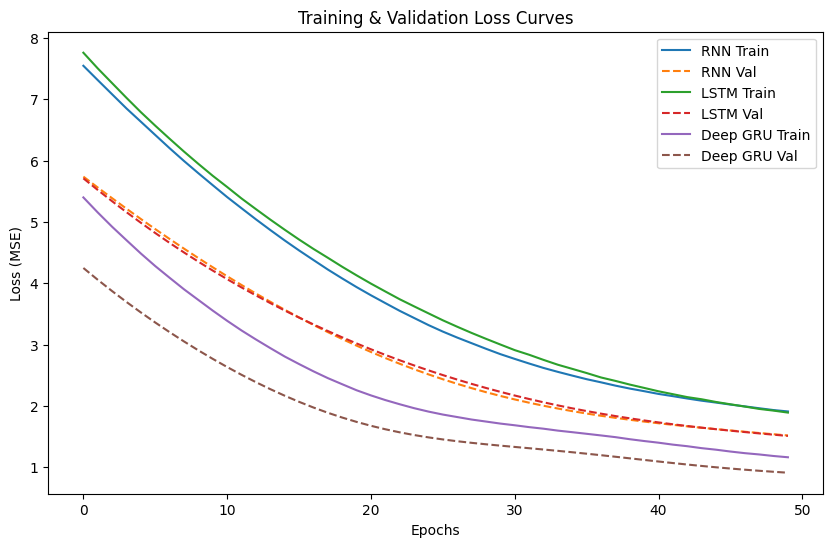

In [ ]:


plt.figure(figsize=(10,6))

for name, (train_loss, val_loss) in loss_history.items():
    plt.plot(train_loss, label=f"{name} Train")
    if len(val_loss) > 0:
        plt.plot(val_loss, linestyle='--', label=f"{name} Val")

plt.title("Training & Validation Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

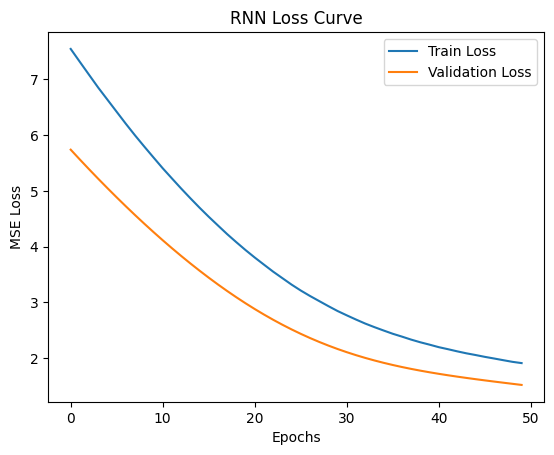

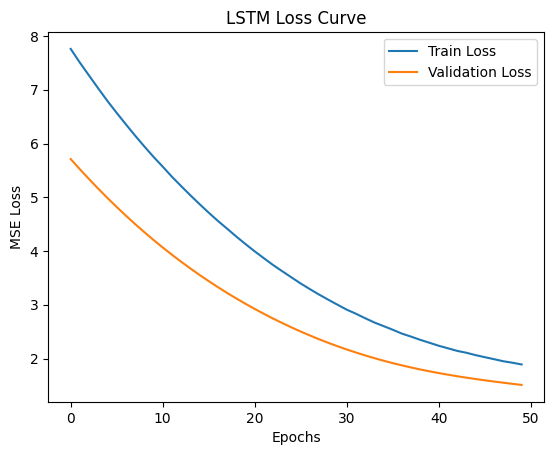

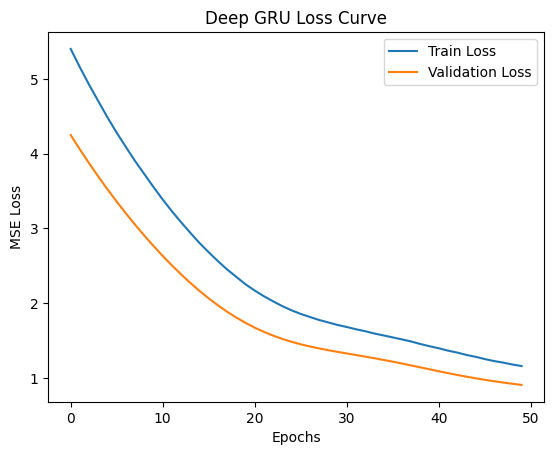

In [ ]:
# Cell 13

for name, (train_loss, val_loss) in loss_history.items():
    plt.figure()
    plt.plot(train_loss, label="Train Loss")
    if len(val_loss) > 0:
        plt.plot(val_loss, label="Validation Loss")

    plt.title(f"{name} Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()

In [ ]:
# Cell: Accuracy metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_gru_val = mean_squared_error(true_signal, pred_signal_gru)
mae_gru_val = mean_absolute_error(true_signal, pred_signal_gru)
mse_lstm_val = mean_squared_error(true_signal, pred_signal_lstm)
mae_lstm_val = mean_absolute_error(true_signal, pred_signal_lstm)
mse_rnn_val = mean_squared_error(true_signal, pred_signal_rnn)
mae_rnn_val = mean_absolute_error(true_signal, pred_signal_rnn)
rmse_gru = np.sqrt(mse_gru_val)
rmse_lstm = np.sqrt(mse_lstm_val)
rmse_rnn = np.sqrt(mse_rnn_val)
print("MSE(GRU) :", mse_gru_val)
print("RMSE(GRU):", rmse_gru)
print("MAE(GRU) :", mae_gru_val)
print("MSE(LSTM):", mse_lstm_val)
print("RMSE(LSTM):", rmse_lstm)
print("MAE(LSTM):", mae_lstm_val)
print("MSE(RNN) :", mse_rnn_val)
print("RMSE(RNN):", rmse_rnn)
print("MAE(RNN) :", mae_rnn_val)

MSE(GRU) : 1.304585576057434
RMSE(GRU): 1.142184563044622
MAE(GRU) : 0.6761378645896912
MSE(LSTM): 1.3335537910461426
RMSE(LSTM): 1.1547959954234959
MAE(LSTM): 0.7603012919425964
MSE(RNN) : 1.5997523069381714
RMSE(RNN): 1.2648131509982696
MAE(RNN) : 0.8419444561004639
